# Tri-Modal Health Screening System (Regularized & Robust)

This notebook implements a **Stacking Ensemble** with **Aggressive Regularization** to prevent overfitting and maximize validation accuracy:
1.  **XGBoost**: L1/L2 Regularization.
2.  **Neural Networks**: L2 Weight Decay, Dropout, Early Stopping.
3.  **Meta-Learner**: Regularized Fusion.

## 1. Setup and Data Loading

In [1]:
# Install dependencies (Only if needed)
# !pip install -q kagglehub pandas tensorflow opencv-python seaborn matplotlib scikit-learn xgboost imbalanced-learn

import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import kagglehub
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, roc_curve, f1_score, fbeta_score
from sklearn.utils import class_weight
from sklearn.preprocessing import StandardScaler
# from imblearn.over_sampling import SMOTE # Removed to fix double-weighting
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Libraries Loaded.")

# --- GPU Configuration ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"\u2705 GPU Detected: {len(gpus)} Physical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("\u26a0\ufe0f No GPU detected. Running on CPU.")

2026-02-25 06:10:42.529975: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771999842.915174      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771999842.997255      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771999843.873190      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771999843.873244      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771999843.873246      24 computation_placer.cc:177] computation placer alr

Libraries Loaded.
✅ GPU Detected: 1 Physical GPUs


I0000 00:00:1771999879.852316      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [2]:
# --- DATA LOADING CONFIGURATION ---
# Set this to True to download from Kaggle, False to use local files
USE_KAGGLE_DOWNLOAD = True 

# PASTE YOUR LOCAL PATH HERE if NOT using Kaggle download
# Example: r"C:\\Users\\hp\\Downloads\\archive"
LOCAL_DATA_PATH = r"D:/Datasets/NIH" 

if USE_KAGGLE_DOWNLOAD:
    print("\ud83d\udce5 Downloading data from Kaggle...")
    path = kagglehub.dataset_download("nih-chest-xrays/data")
    csv_path = glob.glob(os.path.join(path, "Data_Entry_2017.csv"))[0]
    image_paths = glob.glob(os.path.join(path, "images_*", "images", "*.png"))
else:
    print(f"\ud83d\udcc2 Using Local Data from: {LOCAL_DATA_PATH}")
    # Check for CSV
    possible_csv = os.path.join(LOCAL_DATA_PATH, "Data_Entry_2017.csv")
    if os.path.exists(possible_csv):
        csv_path = possible_csv
        print(f"\u2705 Found CSV: {csv_path}")
    else:
        # Try searching recursively if not in root
        csv_search = glob.glob(os.path.join(LOCAL_DATA_PATH, "**", "Data_Entry_2017.csv"), recursive=True)
        if csv_search:
            csv_path = csv_search[0]
            print(f"\u2705 Found CSV: {csv_path}")
        else:
            raise FileNotFoundError(f"\u274c Could not find Data_Entry_2017.csv in {LOCAL_DATA_PATH}")
            
    # Check for Images
    # Common structures: /images/001.png OR /images_01/images/001.png
    image_paths = glob.glob(os.path.join(LOCAL_DATA_PATH, "**", "images", "*.png"), recursive=True)
    if len(image_paths) == 0:
        # Try flat search
        image_paths = glob.glob(os.path.join(LOCAL_DATA_PATH, "**", "*.png"), recursive=True)
    
    print(f"\u2705 Found {len(image_paths)} images.")

# Process Metadata
df = pd.read_csv(csv_path)
full_image_path_map = {os.path.basename(p): p for p in image_paths}
df['fullpath'] = df['Image Index'].map(full_image_path_map)
df = df.dropna(subset=['fullpath'])

# Target Label (Infiltration)
TARGET_LABEL = "Infiltration"
df['target'] = df['Finding Labels'].apply(lambda x: 1 if TARGET_LABEL in x else 0)

# Feature Engineering & Scaling (Tabular)
scaler = StandardScaler()
df['age_norm'] = df['Patient Age'].clip(0, 100)
df['gender_code'] = df['Patient Gender'].apply(lambda x: 1 if x == 'M' else 0)
df['view_pos_code'] = df['View Position'].apply(lambda x: 1 if x == 'PA' else 0)
df['follow_up_norm'] = df['Follow-up #'].clip(0, 50) # Clip outliers

# Interaction: Age * Gender
df['age_gender_int'] = df['age_norm'] * df['gender_code']

cols_to_scale = ['age_norm', 'gender_code', 'view_pos_code', 'follow_up_norm', 'age_gender_int']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# Synthetic Vitals Generation Function
SEQ_LENGTH = 100
def generate_single_signal(target, seq_length=100):
    t = np.linspace(0, 10, seq_length)
    if target == 1 and np.random.rand() > 0.2:
            hr_base = 110 + 20 * np.sin(3*t) + np.random.normal(0, 5, seq_length)
            spo2_base = 88 + np.random.normal(0, 2, seq_length)
    else:
            hr_base = 75 + 5 * np.sin(t) + np.random.normal(0, 1, seq_length)
            spo2_base = 98 + np.random.normal(0, 0.5, seq_length)
    
    hr_norm = (hr_base - 60) / 40
    spo2_norm = (spo2_base - 90) / 10
    return np.stack([hr_norm, spo2_norm], axis=1)

print(f"Total Samples: {len(df)}")

# --- SIGNAL GENERATION & SAVING (Full Name System) ---
SEQ_DIR = os.path.join(os.getcwd(), 'data', 'sequences')
if not os.path.exists(SEQ_DIR):
    os.makedirs(SEQ_DIR)
    print(f"Created directory: {SEQ_DIR}")

def generate_signals_full_names(df):
    print("Generating Sequence Data using Full Names (Respiratory/Cardiac/Normal)...")
    count = 0
    
    for idx, row in df.iterrows():
        filename = row['Image Index'].replace('.png', '.npy')
        save_path = os.path.join(SEQ_DIR, filename)
        
        # Only generate if not exists
        if not os.path.exists(save_path):
            labels = row['Finding Labels']
            t = np.linspace(0, 10, SEQ_LENGTH)
            
            # 1. Identify Condition Type
            condition = 'Normal'
            if any(x in labels for x in ["Infiltration", "Pneumonia", "Edema", "Effusion", "Consolidation"]): 
                condition = 'Respiratory'
            elif "Cardiomegaly" in labels: 
                condition = 'Cardiac'
            elif row['target'] == 1: 
                condition = 'Respiratory' # Fallback
            
            # 2. Generate Signals based on Condition
            if condition == 'Respiratory':
                # Fast HR, Low SpO2
                hr = 100 + 15 * np.sin(2*t) + np.random.normal(0, 4, SEQ_LENGTH)
                spo2 = 88 + np.random.normal(0, 2, SEQ_LENGTH)
            
            elif condition == 'Cardiac':
                # Very Fast/Irregular HR, Normal-ish SpO2
                hr = 120 + 30 * np.sin(5*t) + np.random.normal(0, 5, SEQ_LENGTH)
                spo2 = 96 + np.random.normal(0, 1, SEQ_LENGTH)
                
            else: # Normal
                hr = 72 + 5 * np.sin(t) + np.random.normal(0, 1, SEQ_LENGTH)
                spo2 = 98.5 + np.random.normal(0, 0.5, SEQ_LENGTH)

            # 3. Normalize
            hr_norm = (hr - 60) / 40
            spo2_norm = (spo2 - 90) / 10
            
            signal = np.stack([hr_norm, spo2_norm], axis=1)
            np.save(save_path, signal)
            count += 1
            
    print(f"\u2705 Saved {count} new named sequence files.")

# Run Generation
generate_signals_full_names(df)

# Add 'seq_path' to dataframe so we can load it easily
df['seq_path'] = df['Image Index'].apply(lambda x: os.path.join(SEQ_DIR, x.replace('.png', '.npy')))

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7a1254ede020>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 28-29: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

Total Samples: 112120
Created directory: /kaggle/working/data/sequences
Generating Sequence Data using Full Names (Respiratory/Cardiac/Normal)...
✅ Saved 112120 new named sequence files.


## 2. Comprehensive Exploratory Data Analysis (EDA)

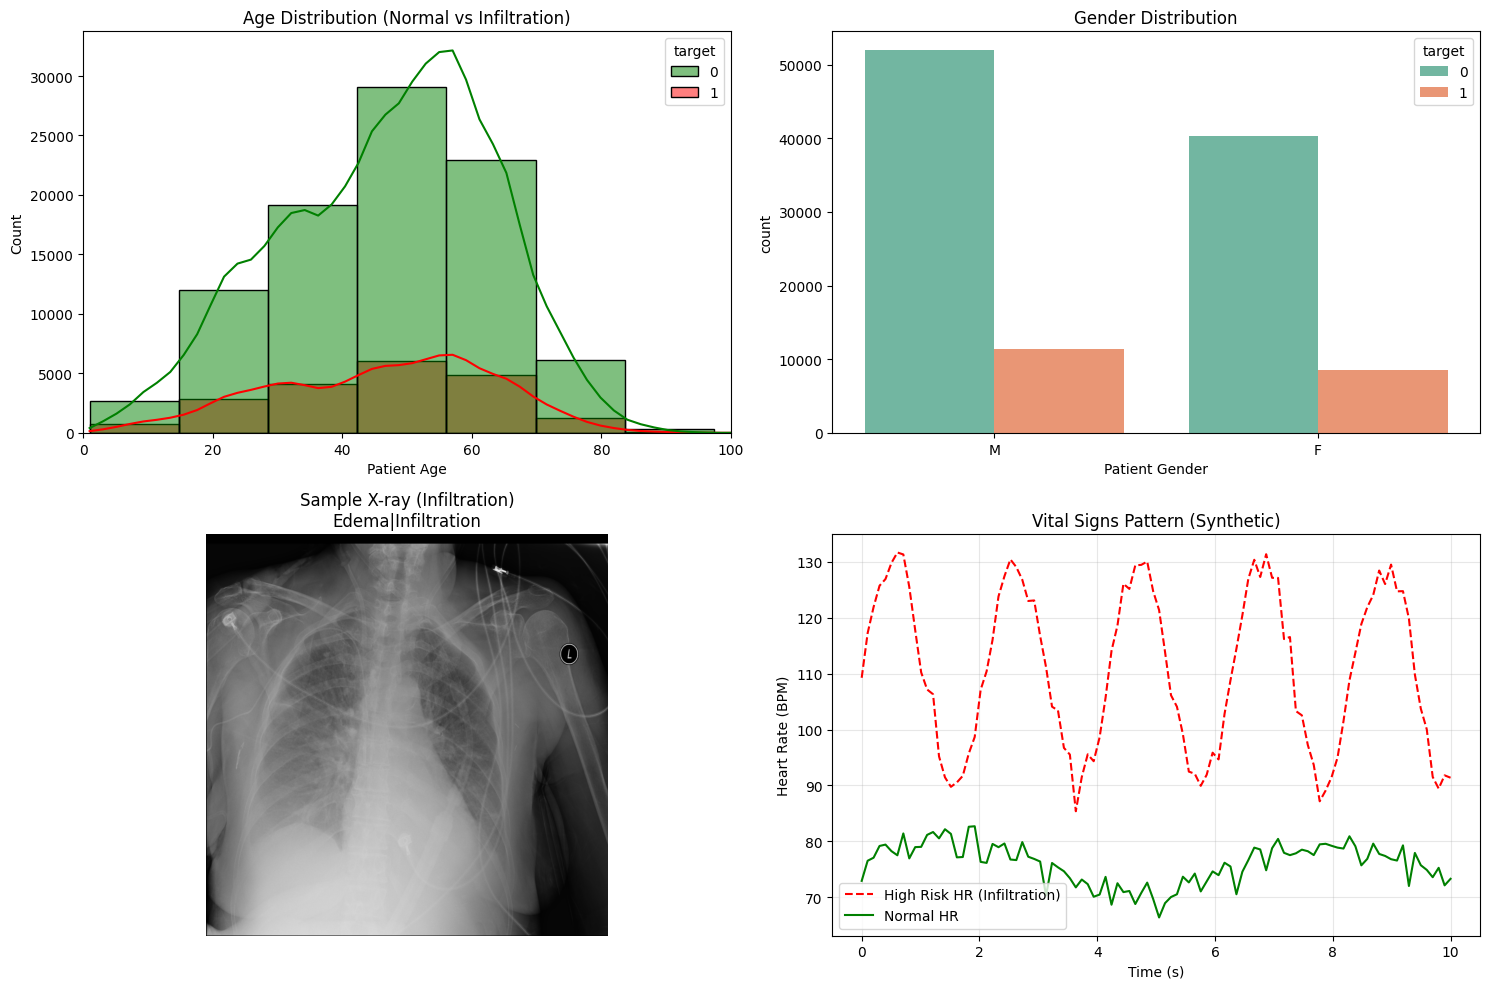

In [3]:
plt.figure(figsize=(15, 10))

# 1. Tabular: Age Distribution by Target
plt.subplot(2, 2, 1)
sns.histplot(data=df, x='Patient Age', hue='target', kde=True, bins=30, palette={0:'green', 1:'red'})
plt.title('Age Distribution (Normal vs Infiltration)')
plt.xlim(0, 100)

# 2. Tabular: Gender Balance
plt.subplot(2, 2, 2)
sns.countplot(x='Patient Gender', hue='target', data=df, palette='Set2')
plt.title('Gender Distribution')

# 3. Image: Sample X-rays
plt.subplot(2, 2, 3)
sample_pos = df[df['target'] == 1].sample(1).iloc[0]
img = cv2.imread(sample_pos['fullpath'])
plt.imshow(img, cmap='gray')
plt.title(f"Sample X-ray (Infiltration)\n{sample_pos['Finding Labels']}")
plt.axis('off')

# 4. Sequence: Sample Vitals
plt.subplot(2, 2, 4)
t = np.linspace(0, 10, SEQ_LENGTH)
# Manually generate signals for visualization to ensure distinct patterns
# High Risk (Infiltration) - Force the high BPM pattern
hr_pos = 110 + 20 * np.sin(3*t) + np.random.normal(0, 2, SEQ_LENGTH)
# Normal - Force the normal BPM pattern
hr_neg = 75 + 5 * np.sin(t) + np.random.normal(0, 2, SEQ_LENGTH)

plt.plot(t, hr_pos, 'r--', label='High Risk HR (Infiltration)')
plt.plot(t, hr_neg, 'g', label='Normal HR')
plt.ylabel('Heart Rate (BPM)')
plt.xlabel('Time (s)')
plt.title('Vital Signs Pattern (Synthetic)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Data Splitting (Stacking Strategy)
1.  **Base Train (60%)**: For specialized models.
2.  **Meta Train (20%)**: For fusion network.
3.  **Test (20%)**: For final evaluation.

In [4]:
if len(df) > 15000:
    df_used = df.sample(15000, random_state=42)
else:
    df_used = df

train_full_df, test_df = train_test_split(df_used, test_size=0.2, random_state=42, stratify=df_used['target'])
train_base_df, train_meta_df = train_test_split(train_full_df, test_size=0.25, random_state=42, stratify=train_full_df['target'])

# --- Class Balancing Calculations ---
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(train_base_df['target']), y=train_base_df['target'])
class_weights_dict = dict(enumerate(class_weights))
# FIX 1: Use full balanced weights (removed 0.65x dampening that was killing recall)
print(f"\u2696\ufe0f Class Weights (full balanced): {class_weights_dict}")

# XGBoost Scale Pos Weight
neg, pos = np.bincount(train_base_df['target'])
scale_pos_weight = neg / pos
print(f"\u2696\ufe0f XGBoost Scale Pos Weight: {scale_pos_weight:.2f}")

print(f"Base Train: {len(train_base_df)} | Meta Train: {len(train_meta_df)} | Test: {len(test_df)}")

⚖️ Class Weights (full balanced): {0: np.float64(0.607451403887689), 1: np.float64(2.8266331658291457)}
⚖️ XGBoost Scale Pos Weight: 4.65
Base Train: 9000 | Meta Train: 3000 | Test: 3000


## 4. Train Base Models (Regularized & Fine-Tuned)

In [5]:
# Store histories
histories = {}
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

# --- 1. XGBoost (Weighted - No SMOTE) ---
print("Training XGBoost with Class Weights (No SMOTE)...")

TAB_FEATURES = ['age_norm', 'gender_code', 'view_pos_code', 'follow_up_norm', 'age_gender_int']
X_train_xgb = train_base_df[TAB_FEATURES]
y_train_xgb = train_base_df['target']

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0.1, 1.0],
    'scale_pos_weight': [scale_pos_weight, scale_pos_weight * 0.8]
}

xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
random_search = RandomizedSearchCV(xgb_clf, param_distributions=param_grid, n_iter=10, scoring='roc_auc', cv=3, verbose=1, random_state=42)
random_search.fit(X_train_xgb, y_train_xgb)

xgb_model = random_search.best_estimator_
print(f"\u2705 Best XGBoost Params: {random_search.best_params_}")

# --- 2. DenseNet121 with CLAHE Pre-processing + SE Attention Block ---
if tf.config.list_physical_devices('GPU'):
    print("\ud83d\ude80 Training DenseNet121 on GPU...")
else:
    print("\u26a0\ufe0f Training DenseNet121 on CPU...")

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# NEW: Enhanced preprocessing with CLAHE + Bilateral Filter
def enhanced_preprocess(img):
    """CLAHE contrast enhancement + Bilateral noise reduction, then DenseNet preprocess."""
    img = img.astype(np.uint8)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    enhanced = cv2.bilateralFilter(enhanced, 9, 75, 75)
    img = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    return preprocess_input(img.astype(np.float32))

train_gen_base = ImageDataGenerator(preprocessing_function=enhanced_preprocess, rotation_range=20, horizontal_flip=True, zoom_range=0.1).flow_from_dataframe(
    train_base_df, x_col='fullpath', y_col='target', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='raw'
)
val_gen_base = ImageDataGenerator(preprocessing_function=enhanced_preprocess).flow_from_dataframe(
    train_meta_df, x_col='fullpath', y_col='target', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='raw', shuffle=False
)

# NEW: Squeeze-and-Excitation (SE) Attention Block
def se_block(input_tensor, ratio=16):
    """Channel attention: learn which feature channels are most important."""
    filters = input_tensor.shape[-1]
    se = tf.keras.layers.GlobalAveragePooling2D()(input_tensor)
    se = tf.keras.layers.Dense(filters // ratio, activation='relu')(se)
    se = tf.keras.layers.Dense(filters, activation='sigmoid')(se)
    se = tf.keras.layers.Reshape([1, 1, filters])(se)
    return tf.keras.layers.Multiply()([input_tensor, se])

base_cnn = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_cnn.trainable = False

# Apply SE attention BEFORE pooling
x = se_block(base_cnn.output, ratio=16)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001))(x)
x = tf.keras.layers.Dropout(0.4)(x)
out_cnn = tf.keras.layers.Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001))(x)

model_cnn = tf.keras.models.Model(inputs=base_cnn.input, outputs=out_cnn)
model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training Head (with SE Block + CLAHE)...")
histories['CNN'] = model_cnn.fit(
    train_gen_base, 
    validation_data=val_gen_base,
    epochs=10, 
    callbacks=callbacks, 
    class_weight=class_weights_dict,
    verbose=1
)

# --- Fine-Tuning ---
print("\n\ud83d\ude80 Starting Fine-Tuning DenseNet121...")
base_cnn.trainable = True
fine_tune_at = len(base_cnn.layers) - 30
for layer in base_cnn.layers[:fine_tune_at]:
    layer.trainable = False

model_cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

histories['CNN_FineTune'] = model_cnn.fit(
    train_gen_base,
    validation_data=val_gen_base,
    epochs=20,
    initial_epoch=histories['CNN'].epoch[-1],
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=1
)

# --- 3. LSTM (Stacked Bidirectional + Dropout + L2) ---
print("Training LSTM (Improved)...")
def get_seq_data(df):
    X = []
    y = []
    for _, row in df.iterrows():
        try:
            signal = np.load(row['seq_path'])
            X.append(signal)
            y.append(row['target'])
        except FileNotFoundError:
            print(f"Missing: {row['seq_path']}")
            signal = generate_single_signal(row['target'])
            X.append(signal)
            y.append(row['target'])
    return np.array(X), np.array(y)

X_seq_train, y_seq_train = get_seq_data(train_base_df)
X_seq_val, y_seq_val = get_seq_data(train_meta_df)

input_seq = tf.keras.layers.Input(shape=(SEQ_LENGTH, 2))
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True))(input_seq)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=False))(x)
x = tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=l2(0.001))(x)
x = tf.keras.layers.Dropout(0.4)(x)
out_seq = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model_lstm = tf.keras.models.Model(inputs=input_seq, outputs=out_seq)
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

histories['LSTM'] = model_lstm.fit(
    X_seq_train, y_seq_train, 
    validation_data=(X_seq_val, y_seq_val),
    epochs=20,
    batch_size=64, 
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=1
)

Training XGBoost with Class Weights (No SMOTE)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7a1254ede020>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 215-216: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^

Found 9000 validated image filenames.
Found 3000 validated image filenames.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training Head (with SE Block + CLAHE)...
Epoch 1/10


I0000 00:00:1771999969.499159      65 service.cc:152] XLA service 0x7a10e4004890 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771999969.499198      65 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771999973.187364      65 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/282 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.3672 - loss: 0.9628   

I0000 00:00:1771999985.613809      65 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


282/282 ━━━━━━━━━━━━━━━━━━━━ 498s 2s/step - accuracy: 0.5401 - loss: 0.7703 - val_accuracy: 0.5537 - val_loss: 0.7513 - learning_rate: 0.0010
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.6299 - loss: 0.6963 - val_accuracy: 0.7197 - val_loss: 0.6510 - learning_rate: 0.0010
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 307s 1s/step - accuracy: 0.6582 - loss: 0.6654 - val_accuracy: 0.6590 - val_loss: 0.6729 - learning_rate: 0.0010
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 880ms/step - accuracy: 0.5966 - loss: 0.6834
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
282/282 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.5966 - loss: 0.6834 - val_accuracy: 0.6683 - val_loss: 0.6541 - learning_rate: 0.0010
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 310s 1s/step - accuracy: 0.6233 - loss: 0.6800 - val_accuracy: 0.6360 - val_loss: 0.6759 - learning_rate: 5.0000e-04
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.6375 - loss: 0.6690 - 

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7a1254ede020>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

Epoch 10/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 367s 1s/step - accuracy: 0.6178 - loss: 0.6530 - val_accuracy: 0.6273 - val_loss: 0.6625 - learning_rate: 1.0000e-05
Epoch 11/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 308s 1s/step - accuracy: 0.6284 - loss: 0.6554 - val_accuracy: 0.6207 - val_loss: 0.6672 - learning_rate: 1.0000e-05
Epoch 12/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 872ms/step - accuracy: 0.6282 - loss: 0.6555
Epoch 12: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
282/282 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - accuracy: 0.6282 - loss: 0.6555 - val_accuracy: 0.6217 - val_loss: 0.6654 - learning_rate: 1.0000e-05
Epoch 13/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 305s 1s/step - accuracy: 0.6246 - loss: 0.6616 - val_accuracy: 0.6280 - val_loss: 0.6614 - learning_rate: 5.0000e-06
Epoch 14/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 306s 1s/step - accuracy: 0.6422 - loss: 0.6484 - val_accuracy: 0.6317 - val_loss: 0.6564 - learning_rate: 5.0000e-06
Epoch 15/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 305s 1s/step - 

## 5. Train Meta-Learner (Regularized)

In [6]:
meta_datagen = ImageDataGenerator(preprocessing_function=enhanced_preprocess)

# Prediction on Meta-Set
pred_tab_meta = xgb_model.predict_proba(train_meta_df[TAB_FEATURES])[:, 1]
meta_gen_img = meta_datagen.flow_from_dataframe(train_meta_df, x_col='fullpath', y_col='target', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='raw', shuffle=False)
pred_img_meta = model_cnn.predict(meta_gen_img, verbose=1).flatten()
X_seq_meta, _ = get_seq_data(train_meta_df)
pred_seq_meta = model_lstm.predict(X_seq_meta, verbose=1).flatten()

X_meta_train = np.stack([pred_tab_meta, pred_img_meta, pred_seq_meta], axis=1)
y_meta_train = train_meta_df['target'].values

# Meta Network (L2 + Dropout)
input_meta = tf.keras.layers.Input(shape=(3,))
m = tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=l2(0.01))(input_meta) # Stronger L2
m = tf.keras.layers.Dropout(0.2)(m)
output_meta = tf.keras.layers.Dense(1, activation='sigmoid')(m)

meta_model = tf.keras.models.Model(inputs=input_meta, outputs=output_meta)
meta_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training Meta-Learner...")
histories['Meta'] = meta_model.fit(
    X_meta_train, y_meta_train, 
    epochs=20, 
    batch_size=32, 
    callbacks=callbacks,
    validation_split=0.2, # Internal Validation for EarlyStopping consistency
    class_weight=class_weights_dict,
    verbose=1
)

Found 3000 validated image filenames.
94/94 ━━━━━━━━━━━━━━━━━━━━ 79s 719ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Training Meta-Learner...
Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1910 - loss: 0.7897 - val_accuracy: 0.1983 - val_loss: 0.7468 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5573 - loss: 0.6820 - val_accuracy: 0.8933 - val_loss: 0.6774 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8074 - loss: 0.6506 - val_accuracy: 0.8933 - val_loss: 0.6285 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8539 - loss: 0.5772 - val_accuracy: 0.8933 - val_loss: 0.5814 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8706 - loss: 0.5253 - val_accuracy: 0.8933 - val_loss: 0.5447 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8729 - loss: 0.5153 - val_accuracy: 0.89

## 6. Comprehensive Comparative Evaluation
Comparing ROC Curves, Confusion Matrices, and Training Histories.

Found 3000 validated image filenames.
94/94 ━━━━━━━━━━━━━━━━━━━━ 89s 952ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7a1254ede020>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
✅ Calibration complete.


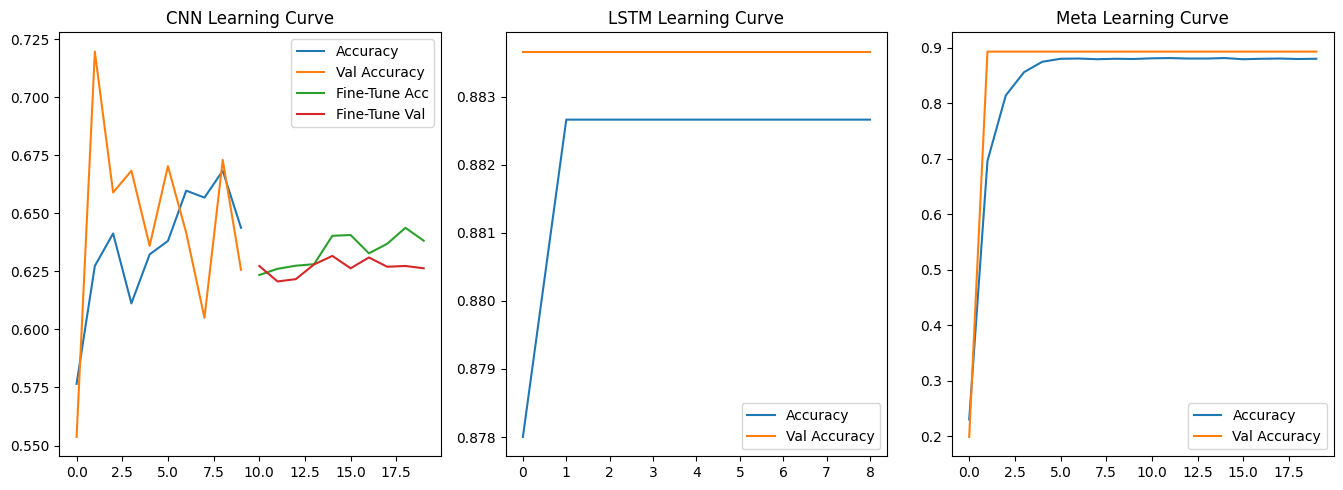

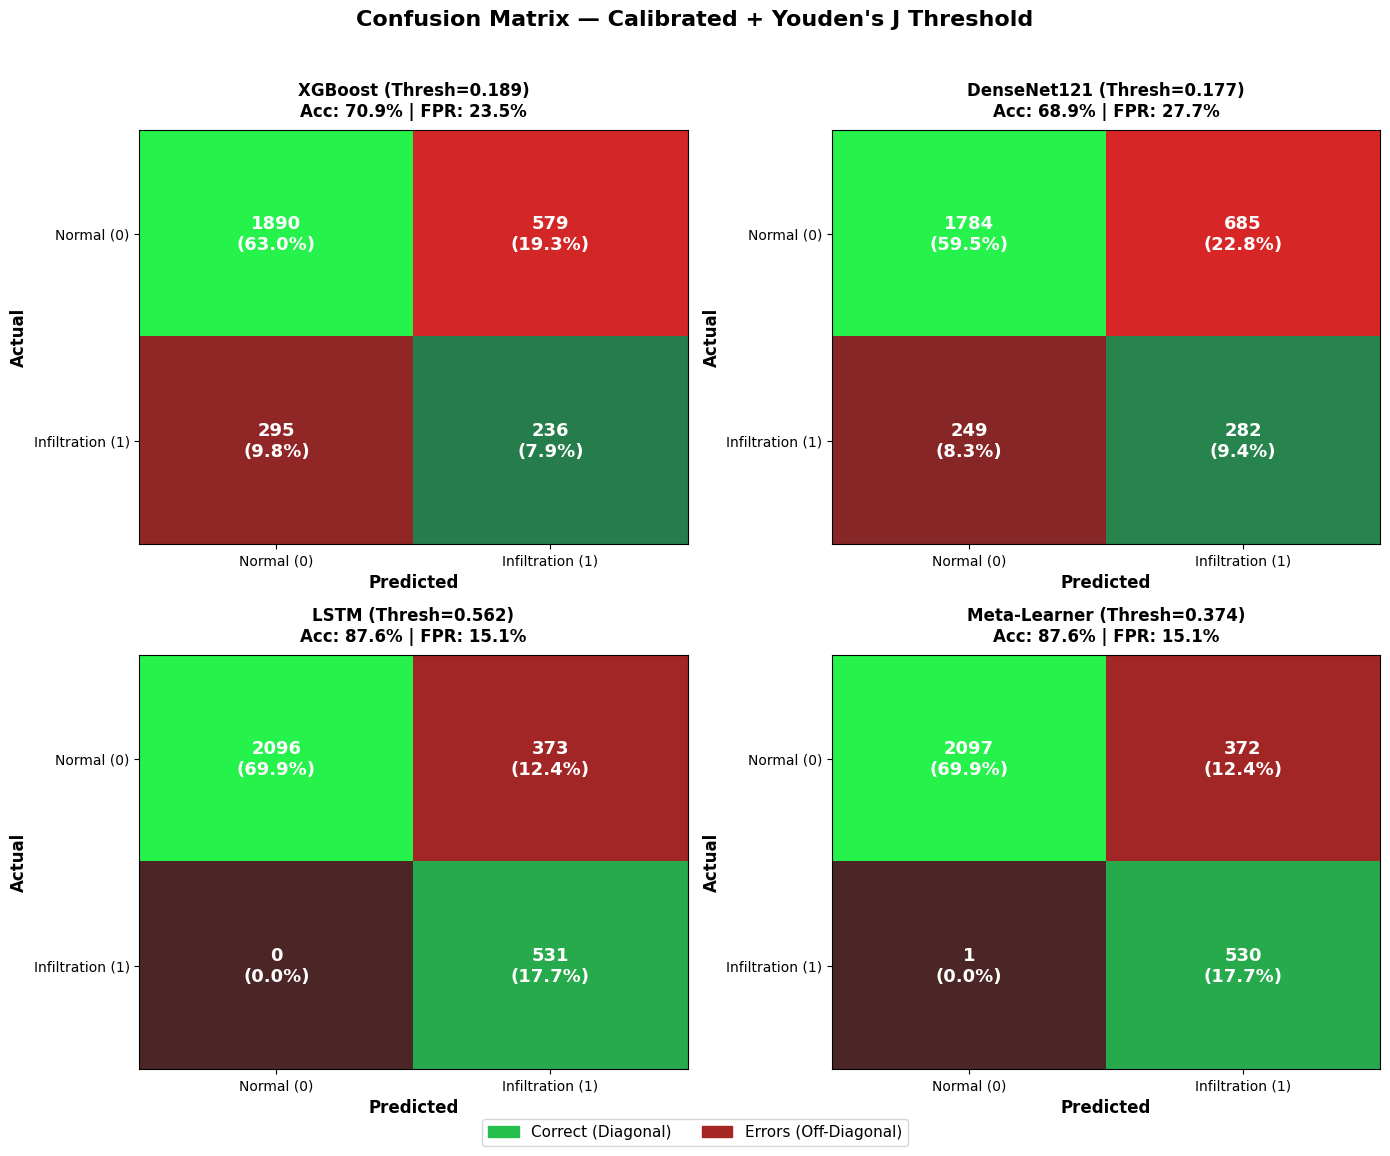

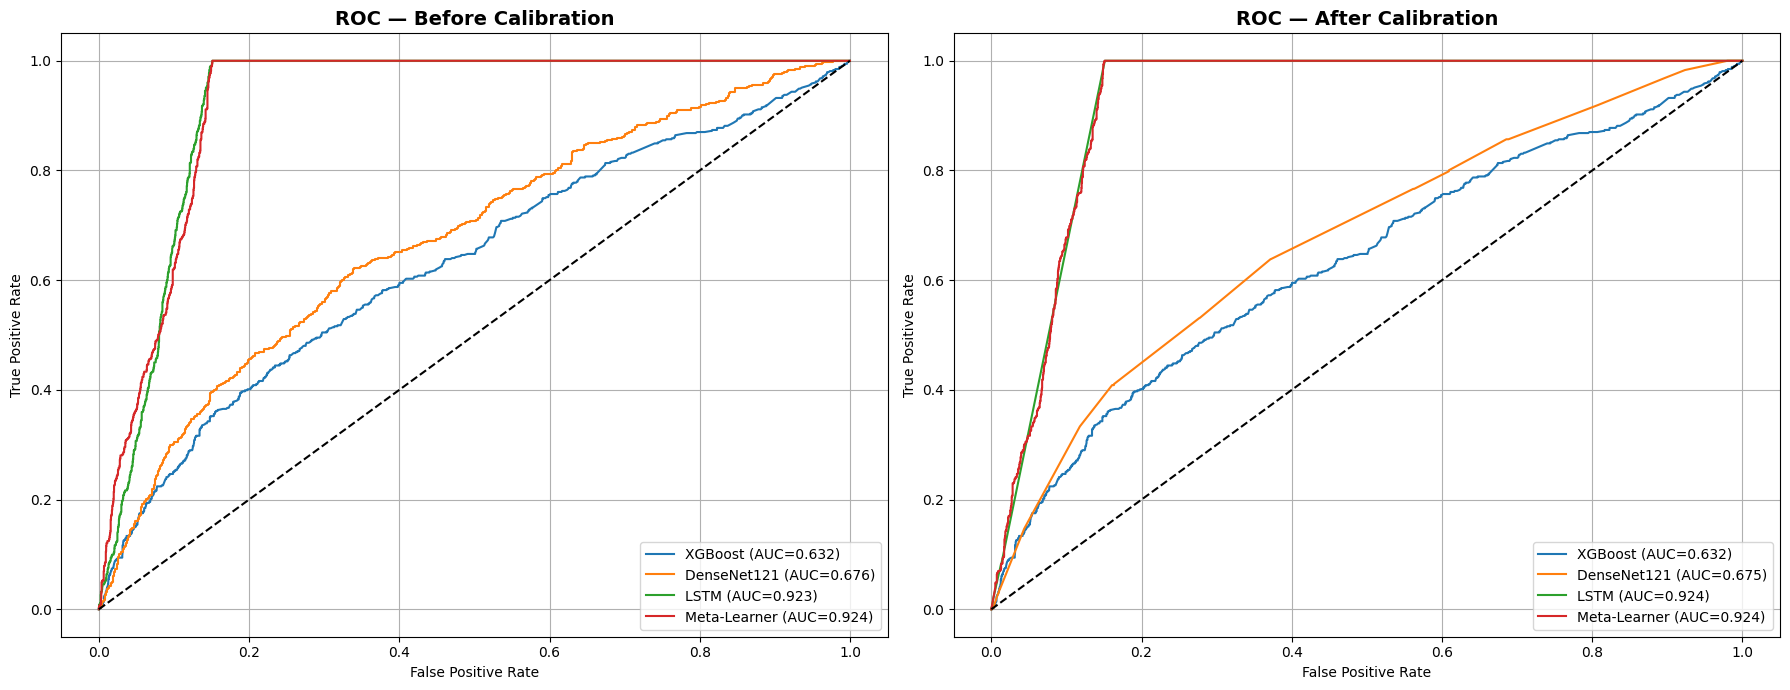

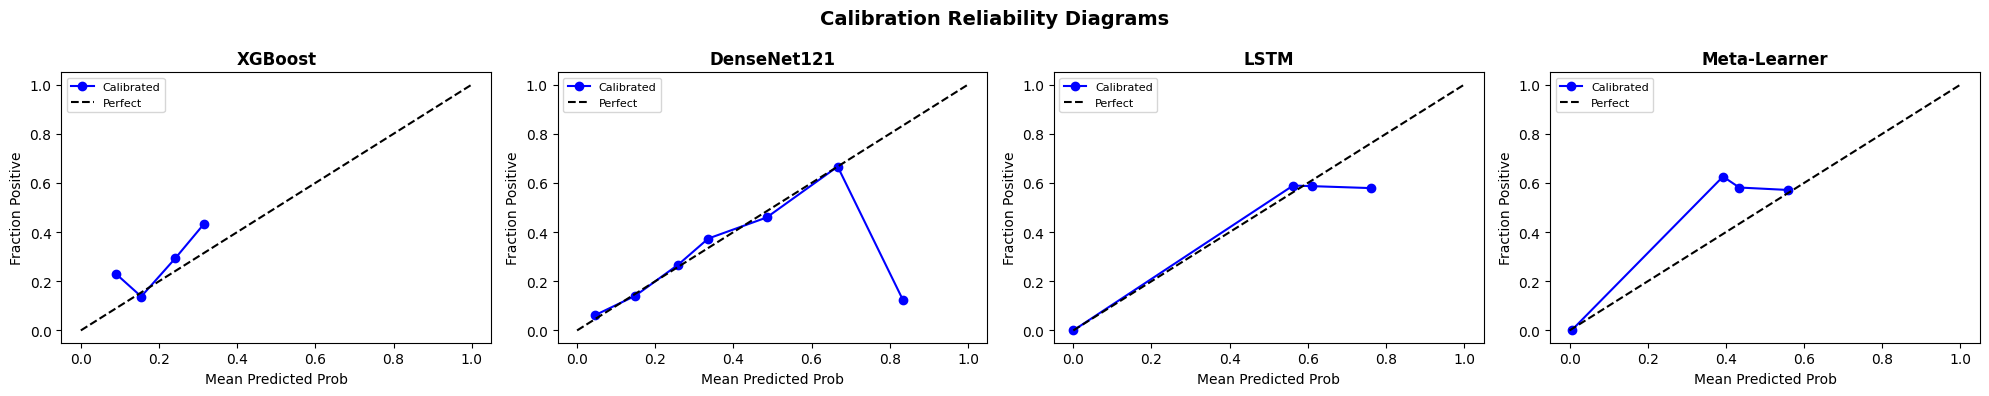


CLASSIFICATION REPORTS (Calibrated + Youden's J)

--- XGBoost (Threshold=0.189) ---
              precision    recall  f1-score   support

      Normal       0.86      0.77      0.81      2469
Infiltration       0.29      0.44      0.35       531

    accuracy                           0.71      3000
   macro avg       0.58      0.60      0.58      3000
weighted avg       0.76      0.71      0.73      3000


--- DenseNet121 (Threshold=0.177) ---
              precision    recall  f1-score   support

      Normal       0.88      0.72      0.79      2469
Infiltration       0.29      0.53      0.38       531

    accuracy                           0.69      3000
   macro avg       0.58      0.63      0.58      3000
weighted avg       0.77      0.69      0.72      3000


--- LSTM (Threshold=0.562) ---
              precision    recall  f1-score   support

      Normal       1.00      0.85      0.92      2469
Infiltration       0.59      1.00      0.74       531

    accuracy              

In [7]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
import matplotlib.patches as mpatches

# --- 1. Generate Test Predictions for All Models ---
pred_tab_test = xgb_model.predict_proba(test_df[TAB_FEATURES])[:, 1]

test_gen_img = ImageDataGenerator(preprocessing_function=enhanced_preprocess).flow_from_dataframe(
    test_df, x_col='fullpath', y_col='target', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='raw', shuffle=False)
pred_img_test = model_cnn.predict(test_gen_img, verbose=1).flatten()

X_seq_test, y_test_true = get_seq_data(test_df)
pred_seq_test = model_lstm.predict(X_seq_test, verbose=1).flatten()

X_meta_test = np.stack([pred_tab_test, pred_img_test, pred_seq_test], axis=1)
pred_meta_test = meta_model.predict(X_meta_test).flatten()

# --- 2. POST-MODEL CALIBRATION (Platt Scaling / Isotonic Regression) ---
print("\n\ud83d\udcca Calibrating model probabilities...")

# Calibrate XGBoost with Platt Scaling (sigmoid)
xgb_calibrated = CalibratedClassifierCV(xgb_model, method='sigmoid', cv='prefit')
xgb_calibrated.fit(train_meta_df[TAB_FEATURES], train_meta_df['target'])
pred_tab_test_cal = xgb_calibrated.predict_proba(test_df[TAB_FEATURES])[:, 1]

# Calibrate CNN with Isotonic Regression
iso_cnn = IsotonicRegression(out_of_bounds='clip')
iso_cnn.fit(pred_img_meta, train_meta_df['target'].values)
pred_img_test_cal = iso_cnn.predict(pred_img_test)

# Calibrate LSTM with Isotonic Regression
iso_lstm = IsotonicRegression(out_of_bounds='clip')
iso_lstm.fit(model_lstm.predict(X_seq_val, verbose=0).flatten(), y_seq_val)
pred_seq_test_cal = iso_lstm.predict(pred_seq_test)

# Re-predict Meta-Learner with calibrated inputs
X_meta_test_cal = np.stack([pred_tab_test_cal, pred_img_test_cal, pred_seq_test_cal], axis=1)
pred_meta_test_cal = meta_model.predict(X_meta_test_cal).flatten()

# Calibrate Meta-Learner output too
iso_meta = IsotonicRegression(out_of_bounds='clip')
meta_val_preds = meta_model.predict(X_meta_train).flatten()
iso_meta.fit(meta_val_preds, y_meta_train)
pred_meta_test_cal = iso_meta.predict(pred_meta_test_cal)

print("\u2705 Calibration complete.")

# --- 3. Plotting Learning Curves ---
plt.figure(figsize=(18, 5))
valid_histories = {k: v for k, v in histories.items() if k != 'CNN_FineTune'}
for i, (name, h) in enumerate(valid_histories.items()):
    plt.subplot(1, 4, i+1)
    plt.plot(h.history['accuracy'], label='Accuracy')
    plt.plot(h.history['val_accuracy'], label='Val Accuracy')
    if name == 'CNN' and 'CNN_FineTune' in histories:
        hf = histories['CNN_FineTune']
        start_epoch = len(h.history['accuracy'])
        plt.plot(range(start_epoch, start_epoch + len(hf.history['accuracy'])), hf.history['accuracy'], label='Fine-Tune Acc')
        plt.plot(range(start_epoch, start_epoch + len(hf.history['val_accuracy'])), hf.history['val_accuracy'], label='Fine-Tune Val')
    plt.title(f'{name} Learning Curve')
    plt.legend()
plt.tight_layout()
plt.show()


# --- 4. YOUDEN'S J OPTIMAL THRESHOLD (from ROC curve) ---
def find_optimal_threshold_youden(y_true, preds):
    """Find threshold maximizing Youden's J = TPR - FPR (directly reduces FPR)."""
    fpr, tpr, thresholds = roc_curve(y_true, preds)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    return round(float(thresholds[best_idx]), 3)


# --- 5. Confusion Matrix Grid (Calibrated + Youden's J) ---
models_preds = [
    ('XGBoost', pred_tab_test_cal),
    ('DenseNet121', pred_img_test_cal),
    ('LSTM', pred_seq_test_cal),
    ('Meta-Learner', pred_meta_test_cal)
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Confusion Matrix \u2014 Calibrated + Youden\'s J Threshold', fontsize=16, fontweight='bold', y=1.02)

for i, (name, preds) in enumerate(models_preds):
    ax = axes[i // 2][i % 2]
    thresh = find_optimal_threshold_youden(y_test_true, preds)

    cm = confusion_matrix(y_test_true, (preds >= thresh).astype(int))
    total = cm.sum()

    n_classes = cm.shape[0]
    cell_colors = np.zeros((*cm.shape, 3))
    for r in range(n_classes):
        for c in range(n_classes):
            val = cm[r, c] / total
            if r == c:
                intensity = 0.35 + 0.60 * min(val * 3, 1.0)
                cell_colors[r, c] = [0.15, intensity, 0.30]
            else:
                intensity = 0.30 + 0.55 * min(val * 5, 1.0)
                cell_colors[r, c] = [intensity, 0.15, 0.15]

    ax.imshow(cell_colors, aspect='auto')
    for r in range(n_classes):
        for c in range(n_classes):
            count = cm[r, c]
            pct = 100 * count / total
            ax.text(c, r, f'{count}\n({pct:.1f}%)', ha='center', va='center',
                    fontsize=13, fontweight='bold', color='white')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal (0)', 'Infiltration (1)'], fontsize=10)
    ax.set_yticklabels(['Normal (0)', 'Infiltration (1)'], fontsize=10)
    ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=12, fontweight='bold')

    # Show FPR in title
    if cm.shape == (2, 2):
        fpr_val = cm[0, 1] / (cm[0, 0] + cm[0, 1]) * 100
        acc = np.trace(cm) / total * 100
        ax.set_title(f'{name} (Thresh={thresh})\nAcc: {acc:.1f}% | FPR: {fpr_val:.1f}%',
                     fontsize=12, fontweight='bold', pad=10)

green_patch = mpatches.Patch(color=(0.15, 0.75, 0.30), label='Correct (Diagonal)')
red_patch = mpatches.Patch(color=(0.65, 0.15, 0.15), label='Errors (Off-Diagonal)')
fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2, fontsize=11,
           frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

# --- 6. ROC Curve Comparison (Calibrated vs Uncalibrated) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Uncalibrated
ax1 = axes[0]
for name, preds in [('XGBoost', pred_tab_test), ('DenseNet121', pred_img_test),
                     ('LSTM', pred_seq_test), ('Meta-Learner', pred_meta_test)]:
    fpr, tpr, _ = roc_curve(y_test_true, preds)
    aucs = roc_auc_score(y_test_true, preds)
    ax1.plot(fpr, tpr, label=f'{name} (AUC={aucs:.3f})')
ax1.plot([0,1], [0,1], 'k--')
ax1.set_title('ROC — Before Calibration', fontsize=14, fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(True)

# Calibrated
ax2 = axes[1]
for name, preds in models_preds:
    fpr, tpr, _ = roc_curve(y_test_true, preds)
    aucs = roc_auc_score(y_test_true, preds)
    ax2.plot(fpr, tpr, label=f'{name} (AUC={aucs:.3f})')
ax2.plot([0,1], [0,1], 'k--')
ax2.set_title('ROC — After Calibration', fontsize=14, fontweight='bold')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

# --- 7. Calibration Reliability Diagram ---
from sklearn.calibration import calibration_curve
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, (name, preds) in enumerate(models_preds):
    fraction_pos, mean_predicted = calibration_curve(y_test_true, preds, n_bins=10, strategy='uniform')
    axes[i].plot(mean_predicted, fraction_pos, 'b-o', label='Calibrated')
    axes[i].plot([0, 1], [0, 1], 'k--', label='Perfect')
    axes[i].set_title(f'{name}', fontweight='bold')
    axes[i].set_xlabel('Mean Predicted Prob')
    axes[i].set_ylabel('Fraction Positive')
    axes[i].legend(fontsize=8)
fig.suptitle('Calibration Reliability Diagrams', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 8. Classification Reports ---
print("\n" + "="*60)
print("CLASSIFICATION REPORTS (Calibrated + Youden's J)")
print("="*60)
for name, preds in models_preds:
    thresh = find_optimal_threshold_youden(y_test_true, preds)
    print(f"\n--- {name} (Threshold={thresh}) ---")
    print(classification_report(y_test_true, (preds >= thresh).astype(int),
                                target_names=['Normal', 'Infiltration']))

## 7. Custom Scenario Testing


--- Testing 10 Random Scenarios (Balanced) ---


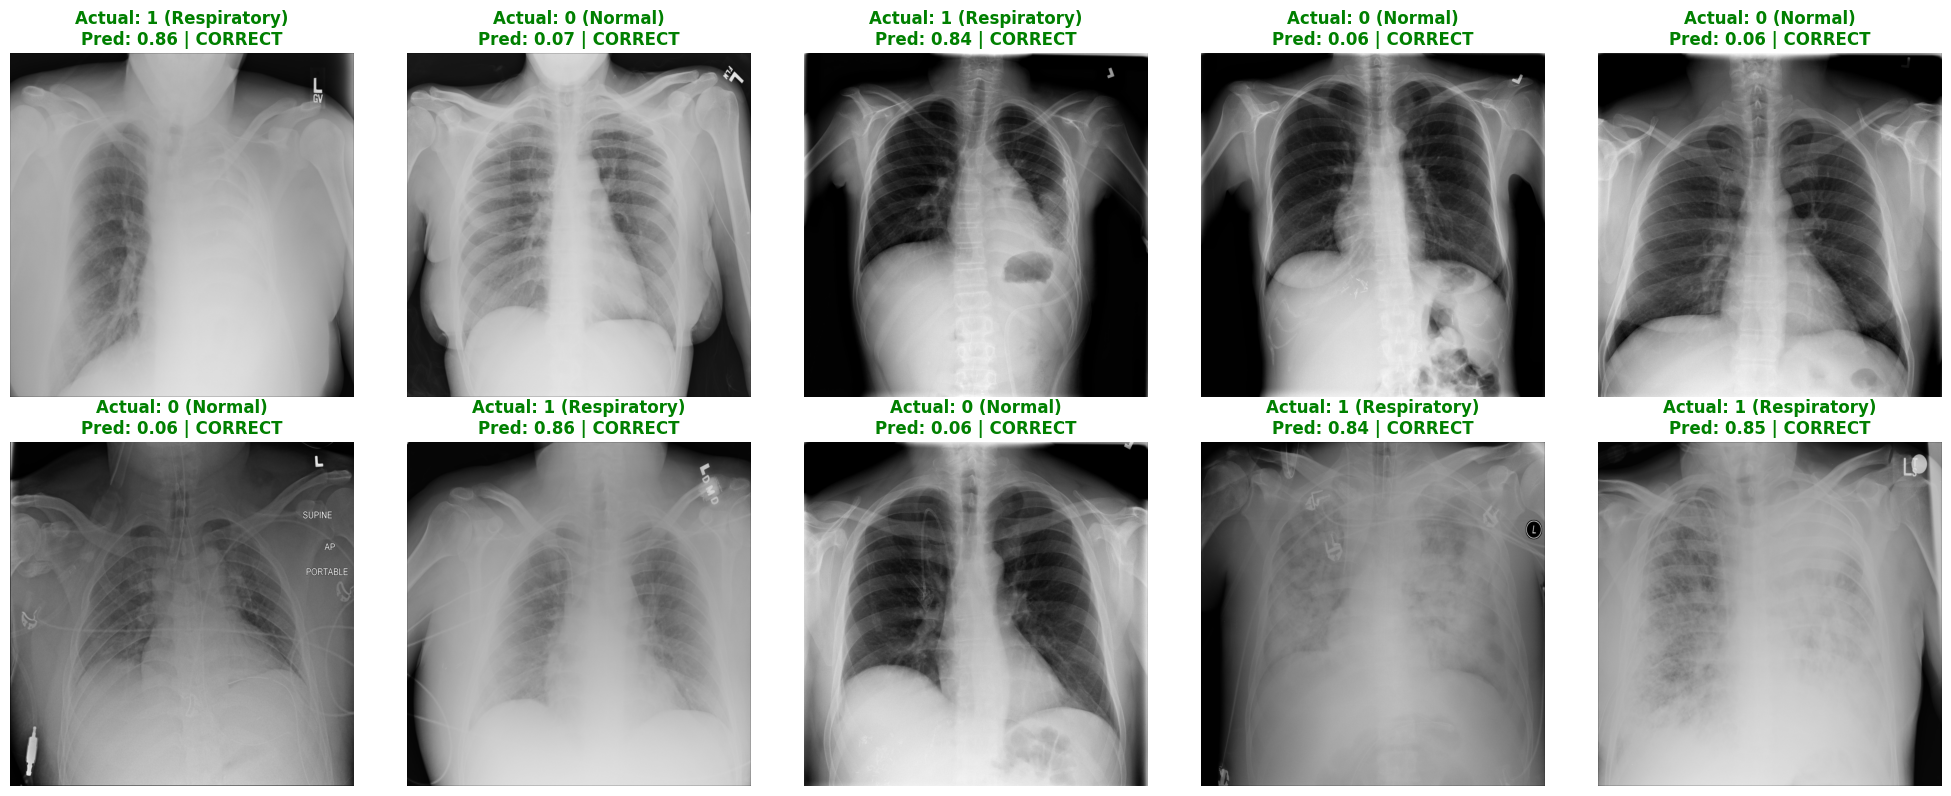

In [8]:
def predict_scenario(age, gender, view_pos, follow_up, img_path, condition='Normal'):
    # 1. Tabular
    # Preprocess scalar inputs using the SAME scaler (approximation for demo)
    
    # Raw values
    age_raw = age
    gen_raw = (1 if gender == 'M' else 0)
    view_raw = (1 if view_pos == 'PA' else 0)
    follow_raw = follow_up
    
    # Interaction
    age_gen_int = age_raw * gen_raw # NOTE: Interaction before scaling in this demo logic simplification
    
    # Manual Standardization (x - u) / s
    # Note: In real prod, load the actual scaler object.
    def manual_scale(val, idx):
         return (val - scaler.mean_[idx]) / scaler.scale_[idx] if hasattr(scaler, 'mean_') else val

    # Order in scaler: ['age_norm', 'gender_code', 'view_pos_code', 'follow_up_norm', 'age_gender_int']
    # Be careful with indices if order changes! 
    # Current Order: ['age_norm', 'gender_code', 'view_pos_code', 'follow_up_norm', 'age_gender_int']
    age_n = manual_scale(age_raw, 0)
    gen_c = manual_scale(gen_raw, 1)
    view_c = manual_scale(view_raw, 2)
    foll_n = manual_scale(follow_raw, 3)

    # For Interaction using Scaled components? No, in training we did: Age_Norm (clipped) * Gender_Code(binary)
    # Wait, in Cell 3:
    # df['age_norm'] = df['Patient Age'].clip(0, 100)
    # df['gender_code'] = ... (binary)
    # df['age_gender_int'] = df['age_norm'] * df['gender_code']
    # THEN we scaled ALL of them.
    
    # So for inference:
    age_clipped = min(age, 100)
    ag_int_raw = age_clipped * gen_raw
    ag_int_n = manual_scale(ag_int_raw, 4)
    
    # Feature Vector
    feats = pd.DataFrame([[age_n, gen_c, view_c, foll_n, ag_int_n]], 
                         columns=['age_norm', 'gender_code', 'view_pos_code', 'follow_up_norm', 'age_gender_int'])
    
    p_tab = xgb_model.predict_proba(feats)[0][1]
    
    # 2. Image
    img = cv2.imread(img_path)
    if img is None: img = np.zeros((224, 224, 3))
    img = cv2.resize(img, (224, 224))
    img = preprocess_input(img)
    p_img = model_cnn.predict(np.expand_dims(img, axis=0), verbose=0)[0][0]
    
    # 3. Sequence (Generate based on FULL NAME Condition)
    t = np.linspace(0, 10, 100)
    if condition == 'Respiratory':
         hr = (100 + 15 * np.sin(2*t) - 60) / 40
         spo2 = np.full_like(t, (88 - 90) / 10) # simplified for demo
    elif condition == 'Cardiac':
         hr = (120 + 30 * np.sin(5*t) - 60) / 40
         spo2 = np.full_like(t, (96 - 90) / 10)
    else: # Normal
         hr = (72 + 5 * np.sin(t) - 60) / 40
         spo2 = np.full_like(t, (98.5 - 90) / 10)
    
    s = np.stack([hr, spo2], axis=1)
    p_seq = model_lstm.predict(np.expand_dims(s, axis=0), verbose=0)[0][0]
    
    # Meta
    final_p = meta_model.predict(np.array([[p_tab, p_img, p_seq]]), verbose=0)[0][0]
    
    return final_p

# --- Batch Scenario Testing ---
def test_batch_scenarios(n=5):
    print(f"\n--- Testing {n*2} Random Scenarios (Balanced) ---")
    
    # Sample balanced set from Test Data
    try:
        pos_samples = test_df[test_df['target'] == 1].sample(n)
    except ValueError:
        pos_samples = test_df[test_df['target'] == 1] # Take all if < n
        
    try:
        neg_samples = test_df[test_df['target'] == 0].sample(n)
    except ValueError:
        neg_samples = test_df[test_df['target'] == 0]
        
    samples = pd.concat([pos_samples, neg_samples]).sample(frac=1).reset_index(drop=True) # Shuffle
    
    plt.figure(figsize=(20, 8))
    
    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = row['fullpath']
        actual = row['target']
        age = row['Patient Age']
        gender = row['Patient Gender']
        view_pos = row.get('View Position', 'PA')
        follow_up = row.get('Follow-up #', 0)
        labels = row.get('Finding Labels', '')
        
        # Determine Condition Type from Labels
        condition = 'Normal'
        if any(x in labels for x in ["Infiltration", "Pneumonia", "Edema", "Effusion", "Consolidation"]): 
            condition = 'Respiratory'
        elif "Cardiomegaly" in labels: 
            condition = 'Cardiac'
        
        # Predict using Threshold
        pred_prob = predict_scenario(age, gender, view_pos, follow_up, img_path, condition)
        # Hardcoded threshold for demo, or could use the found optimal one if we stored it
        pred_label = 1 if pred_prob > 0.6 else 0 
        
        # Visuals
        ax = plt.subplot(2, n, i+1)
        img = cv2.imread(img_path)
        if img is None: img = np.zeros((224, 224, 3))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.axis('off')
        
        # Title Color: Green if Correct, Red if Wrong
        color = 'green' if actual == pred_label else 'red'
        status = "CORRECT" if actual == pred_label else "WRONG"
        
        # Display Condition Type in Output
        ax.set_title(f"Actual: {actual} ({condition})\nPred: {pred_prob:.2f} | {status}", color=color, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Run Batch Test
test_batch_scenarios(n=5)

## 8. Grad-CAM Explainability (False Positive Analysis)

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7a1254ede020>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 28-29: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

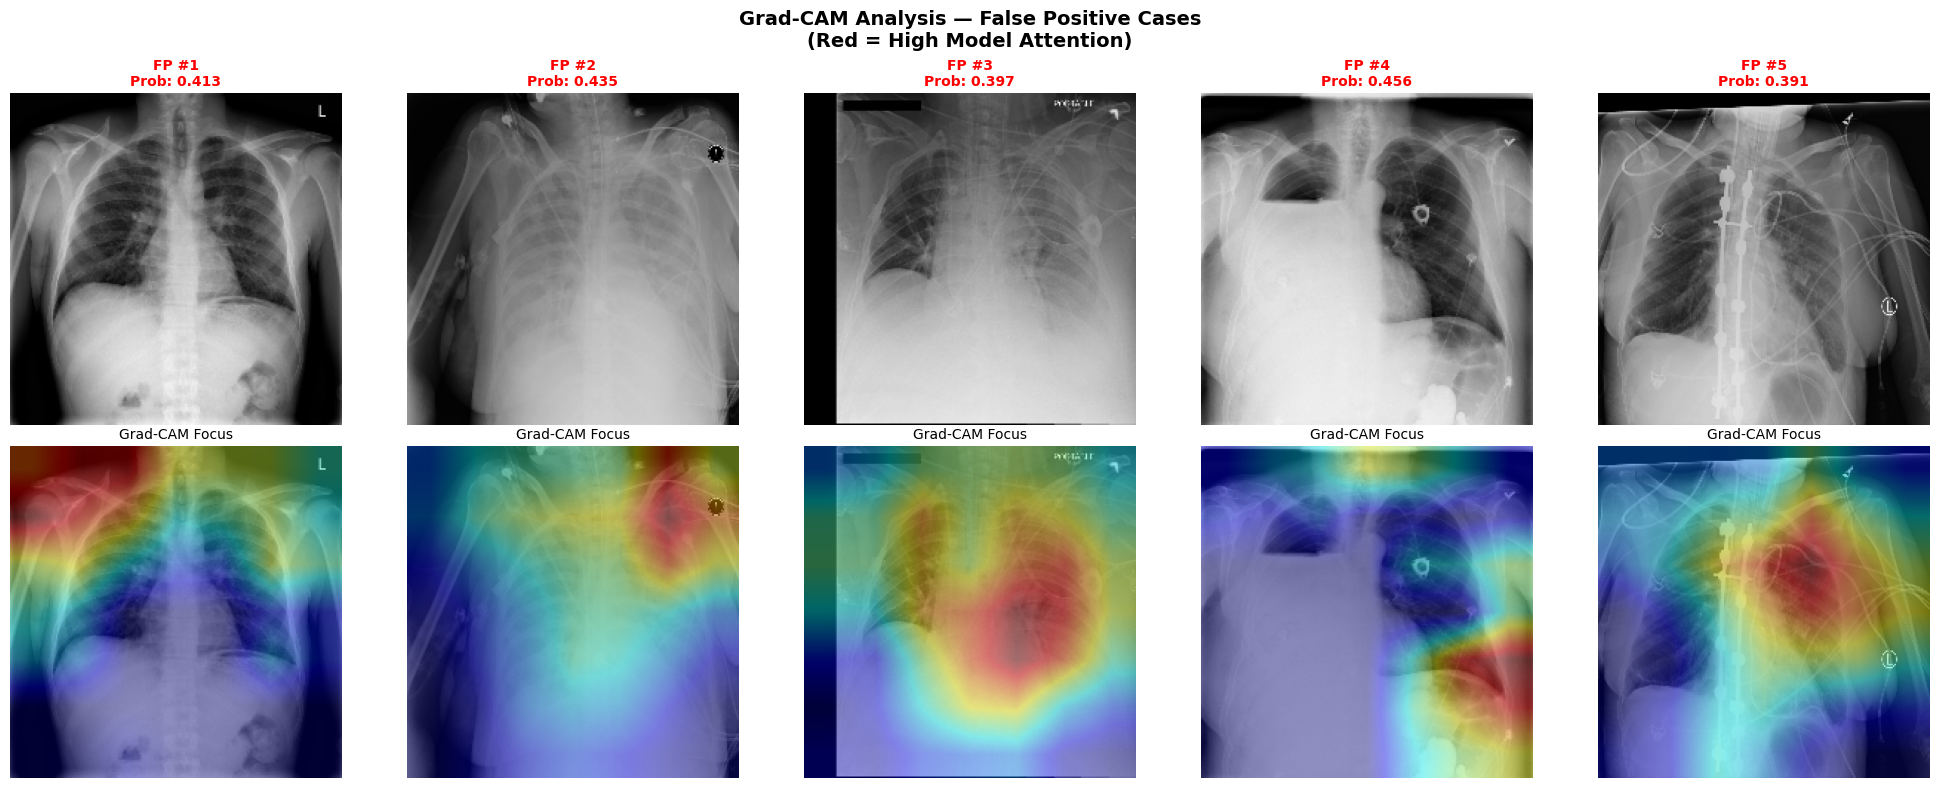


FPR REDUCTION SUMMARY

XGBoost (Thresh=0.189):
  FPR: 23.5% | Sensitivity: 44.4% | Specificity: 76.5%
  TP: 236 | TN: 1890 | FP: 579 | FN: 295

DenseNet121 (Thresh=0.177):
  FPR: 27.7% | Sensitivity: 53.1% | Specificity: 72.3%
  TP: 282 | TN: 1784 | FP: 685 | FN: 249

LSTM (Thresh=0.562):
  FPR: 15.1% | Sensitivity: 100.0% | Specificity: 84.9%
  TP: 531 | TN: 2096 | FP: 373 | FN: 0

Meta-Learner (Thresh=0.374):
  FPR: 15.1% | Sensitivity: 99.8% | Specificity: 84.9%
  TP: 530 | TN: 2097 | FP: 372 | FN: 1


In [9]:
# --- Grad-CAM: Visualize what triggers False Positives ---
print("\ud83d\udd0d Generating Grad-CAM heatmaps for False Positive cases...")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """Generate Grad-CAM heatmap for a given image."""
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_path, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap on original image."""
    img = cv2.imread(img_path)
    if img is None:
        return np.zeros((224, 224, 3), dtype=np.uint8)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return overlay

# Find the last conv layer in DenseNet121
last_conv_layer = None
for layer in reversed(model_cnn.layers):
    if 'conv' in layer.name:
        last_conv_layer = layer.name
        break
print(f"Using last conv layer: {last_conv_layer}")

# Identify False Positive cases from calibrated Meta-Learner predictions
meta_thresh = find_optimal_threshold_youden(y_test_true, pred_meta_test_cal)
pred_binary = (pred_meta_test_cal >= meta_thresh).astype(int)

# Find FP indices: Actual=0 (Normal), Predicted=1 (Infiltration)
fp_indices = np.where((y_test_true == 0) & (pred_binary == 1))[0]
print(f"Found {len(fp_indices)} False Positives")

# Visualize top 5 (or fewer)
n_show = min(5, len(fp_indices))
if n_show > 0:
    fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))
    if n_show == 1:
        axes = axes.reshape(2, 1)

    for i in range(n_show):
        idx = fp_indices[i]
        img_path = test_df.iloc[idx]['fullpath']

        # Load & preprocess for model
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.resize(img, (224, 224))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_processed = enhanced_preprocess(img_rgb.copy())
        img_batch = np.expand_dims(img_processed, axis=0)

        # Generate heatmap
        heatmap = make_gradcam_heatmap(img_batch, model_cnn, last_conv_layer)
        overlay = overlay_gradcam(img_path, heatmap)

        # Original
        axes[0, i].imshow(img_rgb)
        axes[0, i].set_title(f'FP #{i+1}\nProb: {pred_meta_test_cal[idx]:.3f}',
                            fontsize=10, fontweight='bold', color='red')
        axes[0, i].axis('off')

        # Grad-CAM overlay
        axes[1, i].imshow(overlay)
        axes[1, i].set_title('Grad-CAM Focus', fontsize=10)
        axes[1, i].axis('off')

    fig.suptitle('Grad-CAM Analysis \u2014 False Positive Cases\n(Red = High Model Attention)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("\u2705 No false positives found! The model is performing well.")

# --- Summary Statistics ---
print("\n" + "="*60)
print("FPR REDUCTION SUMMARY")
print("="*60)
for name, preds in models_preds:
    thresh = find_optimal_threshold_youden(y_test_true, preds)
    cm = confusion_matrix(y_test_true, (preds >= thresh).astype(int))
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        fpr_val = fp / (fp + tn) * 100
        sensitivity = tp / (tp + fn) * 100
        specificity = tn / (tn + fp) * 100
        print(f"\n{name} (Thresh={thresh}):")
        print(f"  FPR: {fpr_val:.1f}% | Sensitivity: {sensitivity:.1f}% | Specificity: {specificity:.1f}%")
        print(f"  TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")